In [5]:
import pandas as pd
import numpy as np

# Load the dataset
# Make sure to upload your UpworkJobsData.csv file to Colab first
df = pd.read_csv('/content/sample_data/Final_Data_.csv')

print("Original dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for missing values in pricing columns
print("\nMissing values in pricing columns:")
pricing_columns = ['hourly_low', 'hourly_high', 'budget']
for col in pricing_columns:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} missing values")

# Display some sample data to understand the structure
print("\nSample data for pricing columns:")
print(df[pricing_columns].head(10))

# Remove rows where ALL three pricing columns are empty/null
# Keep rows where at least one of the three columns has a value
initial_count = len(df)

# Create a condition to keep rows where at least one pricing column has a value
condition = (
    df['hourly_low'].notna() |
    df['hourly_high'].notna() |
    df['budget'].notna()
)

# Filter the dataframe
df_cleaned = df[condition].copy()

final_count = len(df_cleaned)
removed_count = initial_count - final_count

print(f"\nData cleaning results:")
print(f"Original rows: {initial_count}")
print(f"Rows removed: {removed_count}")
print(f"Remaining rows: {final_count}")
print(f"Percentage removed: {(removed_count/initial_count)*100:.2f}%")

# Display summary of cleaned data
print("\nCleaned dataset summary:")
print(df_cleaned.info())

print("\nMissing values in pricing columns after cleaning:")
for col in pricing_columns:
    missing_count = df_cleaned[col].isna().sum()
    print(f"{col}: {missing_count} missing values")

# Save the cleaned dataset
output_filename = 'UpworkJobsData_cleaned.csv'
df_cleaned.to_csv(output_filename, index=False)

print(f"\nCleaned dataset saved as: {output_filename}")

# Display first few rows of cleaned data
print("\nFirst few rows of cleaned dataset:")
print(df_cleaned.head())

# Additional analysis: Show distribution of job types
print("\nJob type distribution in cleaned data:")
hourly_jobs = df_cleaned['is_hourly'].value_counts()
print("Is Hourly:")
print(hourly_jobs)

# Show some statistics about pricing
print("\nPricing statistics for cleaned data:")
if not df_cleaned['hourly_low'].isna().all():
    print(f"Hourly Low - Min: ${df_cleaned['hourly_low'].min():.2f}, Max: ${df_cleaned['hourly_low'].max():.2f}, Mean: ${df_cleaned['hourly_low'].mean():.2f}")
if not df_cleaned['hourly_high'].isna().all():
    print(f"Hourly High - Min: ${df_cleaned['hourly_high'].min():.2f}, Max: ${df_cleaned['hourly_high'].max():.2f}, Mean: ${df_cleaned['hourly_high'].mean():.2f}")
if not df_cleaned['budget'].isna().all():
    print(f"Budget - Min: ${df_cleaned['budget'].min():.2f}, Max: ${df_cleaned['budget'].max():.2f}, Mean: ${df_cleaned['budget'].mean():.2f}")

# Download the cleaned file (this will work in Google Colab)
from google.colab import files
files.download(output_filename)

Original dataset shape: (53058, 10)

First few rows:
                                               title  \
0  Experienced Media Buyer For Solar Pannel and R...   
1                               Full Stack Developer   
2                                    SMMA Bubble App   
3             Talent Hunter Specialized in Marketing   
4                                      Data Engineer   

                                                link  \
0  https://www.upwork.com/jobs/Experienced-Media-...   
1  https://www.upwork.com/jobs/Full-Stack-Develop...   
2  https://www.upwork.com/jobs/SMMA-Bubble-App_%7...   
3  https://www.upwork.com/jobs/Talent-Hunter-Spec...   
4  https://www.upwork.com/jobs/Data-Engineer_%7E0...   

                                         description  \
0  We’re looking for a talented and hardworking a...   
1  Job Title: Full Stack DeveloperWe are seeking ...   
2  I need someone to redesign my bubble.io site t...   
3  Join Our Growing Team!We are an innovative com

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from google.colab import files

# Set random seed for reproducibility (optional - remove if you want completely random results each time)
random.seed(42)
np.random.seed(42)

# Read the CSV file
filename = '/content/sample_data/UpworkJobsData_cleaned (1).csv'
df = pd.read_csv(filename)

print(f"Original dataset shape: {df.shape}")
print(f"Total rows: {len(df)}")

# Show current published_date values (first few)
print("\nCurrent published_date values (first 10):")
print(df['published_date'].head(10))

# Define date range
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)

# Calculate the total number of days in the range
total_days = (end_date - start_date).days + 1

print(f"\nDate range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Total days in range: {total_days}")

# Generate random dates for each row
def generate_random_date():
    """Generate a random date between start_date and end_date"""
    random_days = random.randint(0, total_days - 1)
    random_date = start_date + timedelta(days=random_days)
    return random_date.strftime('%Y-%m-%d')

# Apply random dates to all rows
print("\nGenerating random dates...")
df['published_date'] = [generate_random_date() for _ in range(len(df))]

print("Random date generation completed!")

# Show the new published_date values (first few)
print("\nNew published_date values (first 10):")
print(df['published_date'].head(10))

# Show some statistics about the generated dates
print(f"\nDate statistics:")
print(f"Earliest date: {df['published_date'].min()}")
print(f"Latest date: {df['published_date'].max()}")
print(f"Total unique dates: {df['published_date'].nunique()}")

# Show distribution by month
df_temp = df.copy()
df_temp['published_date'] = pd.to_datetime(df_temp['published_date'])
df_temp['month'] = df_temp['published_date'].dt.month
monthly_distribution = df_temp['month'].value_counts().sort_index()

print(f"\nDistribution by month:")
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month_num, count in monthly_distribution.items():
    print(f"{months[month_num-1]}: {count} jobs")

# Save the updated file
output_filename = 'WholeYear.csv'
df.to_csv(output_filename, index=False)

print(f"\nUpdated file saved as: {output_filename}")

# Show sample of updated data
print(f"\nSample of updated data:")
print(df[['title', 'published_date', 'is_hourly', 'country']].head())

# Download the updated file
print(f"\nDownloading updated file...")
files.download(output_filename)

print("Done! File with random dates has been downloaded.")

Original dataset shape: (44829, 10)
Total rows: 44829

Current published_date values (first 10):
0    2024-02-17 09:09:54+00:00
1    2024-02-17 09:09:17+00:00
2    2024-02-17 09:08:46+00:00
3    2024-02-17 09:07:42+00:00
4    2024-02-17 09:07:27+00:00
5    2024-02-17 09:07:05+00:00
6    2024-02-17 09:06:21+00:00
7    2024-02-17 09:04:50+00:00
8    2024-02-17 09:04:49+00:00
9    2024-02-17 09:04:14+00:00
Name: published_date, dtype: object

Date range: 2024-01-01 to 2024-12-31
Total days in range: 366

Generating random dates...
Random date generation completed!

New published_date values (first 10):
0    2024-11-23
1    2024-02-27
2    2024-01-13
3    2024-05-20
4    2024-05-05
5    2024-04-24
6    2024-03-12
7    2024-02-22
8    2024-12-12
9    2024-10-06
Name: published_date, dtype: object

Date statistics:
Earliest date: 2024-01-01
Latest date: 2024-12-31
Total unique dates: 366

Distribution by month:
Jan: 3784 jobs
Feb: 3550 jobs
Mar: 3861 jobs
Apr: 3621 jobs
May: 3719 jobs
Jun: 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! File with random dates has been downloaded.


In [8]:
import pandas as pd
from google.colab import files

# Read the CSV file
# Change 'abc.csv' to your actual filename
filename = '/content/sample_data/Final_Data.csv'
df = pd.read_csv(filename)

print(f"Original dataset shape: {df.shape}")
print(f"Total rows: {len(df)}")

# Check the distribution of is_hourly values
print("\nDistribution of is_hourly values:")
print(df['is_hourly'].value_counts())

# Separate the data based on is_hourly column
hourly_jobs = df[df['is_hourly'] == True].copy()
fixed_price_jobs = df[df['is_hourly'] == False].copy()

print(f"\nHourly jobs: {len(hourly_jobs)} rows")
print(f"Fixed price jobs: {len(fixed_price_jobs)} rows")

# Save the separated files
hourly_filename = 'hourly_jobs.csv'
fixed_price_filename = 'fixed_price_jobs.csv'

hourly_jobs.to_csv(hourly_filename, index=False)
fixed_price_jobs.to_csv(fixed_price_filename, index=False)

print(f"\nFiles created:")
print(f"1. {hourly_filename} - Contains {len(hourly_jobs)} hourly jobs")
print(f"2. {fixed_price_filename} - Contains {len(fixed_price_jobs)} fixed price jobs")

# Show sample data from each file
print(f"\nSample from hourly jobs:")
print(hourly_jobs[['title', 'is_hourly', 'hourly_low', 'hourly_high', 'budget']].head(3))

print(f"\nSample from fixed price jobs:")
print(fixed_price_jobs[['title', 'is_hourly', 'hourly_low', 'hourly_high', 'budget']].head(3))

# Download both files
print("\nDownloading files...")
files.download(hourly_filename)
files.download(fixed_price_filename)

print("Done! Both files have been downloaded.")

Original dataset shape: (44829, 10)
Total rows: 44829

Distribution of is_hourly values:
is_hourly
True     22956
False    21873
Name: count, dtype: int64

Hourly jobs: 22956 rows
Fixed price jobs: 21873 rows

Files created:
1. hourly_jobs.csv - Contains 22956 hourly jobs
2. fixed_price_jobs.csv - Contains 21873 fixed price jobs

Sample from hourly jobs:
                                               title  is_hourly  hourly_low  \
2                                    SMMA Bubble App       True        10.0   
5  need Portuguese writers who can understand and...       True         7.0   
9  URGENT: Fix Emails Not Working on Discourse In...       True        40.0   

   hourly_high  budget  
2         30.0     NaN  
5         22.0     NaN  
9         75.0     NaN  

Sample from fixed price jobs:
                                               title  is_hourly  hourly_low  \
0  Experienced Media Buyer For Solar Pannel and R...      False         NaN   
1                               Full 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Both files have been downloaded.


🔍 DEBUGGING LSTM Job Trend Predictor
✅ Data loaded: 44829 rows, 10 columns

📋 Column names: ['title', 'link', 'description', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country', 'category']

🔍 First few rows:
                                               title  \
0  Experienced Media Buyer For Solar Pannel and R...   
1                               Full Stack Developer   
2                                    SMMA Bubble App   
3                                      Data Engineer   
4                   Want to fix the WordPress Plugin   

                                                link  \
0  https://www.upwork.com/jobs/Experienced-Media-...   
1  https://www.upwork.com/jobs/Full-Stack-Develop...   
2  https://www.upwork.com/jobs/SMMA-Bubble-App_%7...   
3  https://www.upwork.com/jobs/Data-Engineer_%7E0...   
4  https://www.upwork.com/jobs/Want-fix-the-WordP...   

                                         description published_date  \
0  We’re looking f

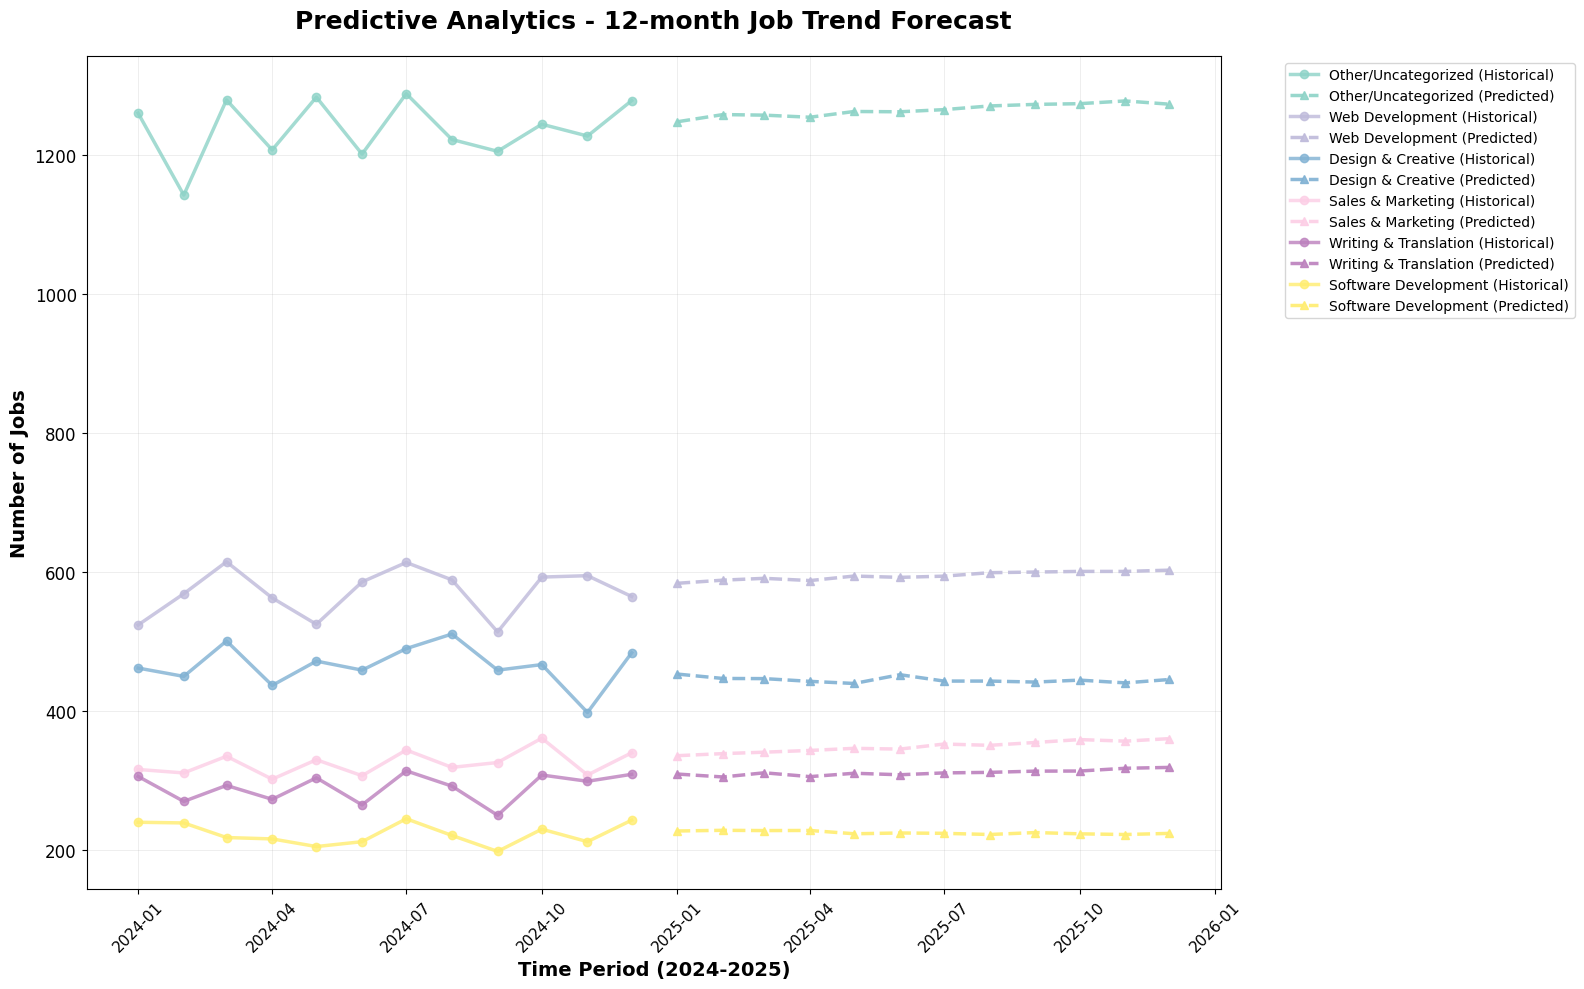


📈 PREDICTION SUMMARY
Category                       Historical Avg  Predicted Avg   Trend      Change %  
--------------------------------------------------------------------------------
Other/Uncategorized            1237.3          1265.4          📈 Growth   2.3       %
Web Development                571.0           594.8           📈 Growth   4.2       %
Design & Creative              465.8           445.1           📉 Decline  -4.4      %
Sales & Marketing              324.9           348.8           📈 Growth   7.3       %
Writing & Translation          290.2           311.4           📈 Growth   7.3       %
Software Development           223.2           225.1           📈 Growth   0.8       %

🎨 Creating individual plots for all 6 categories...


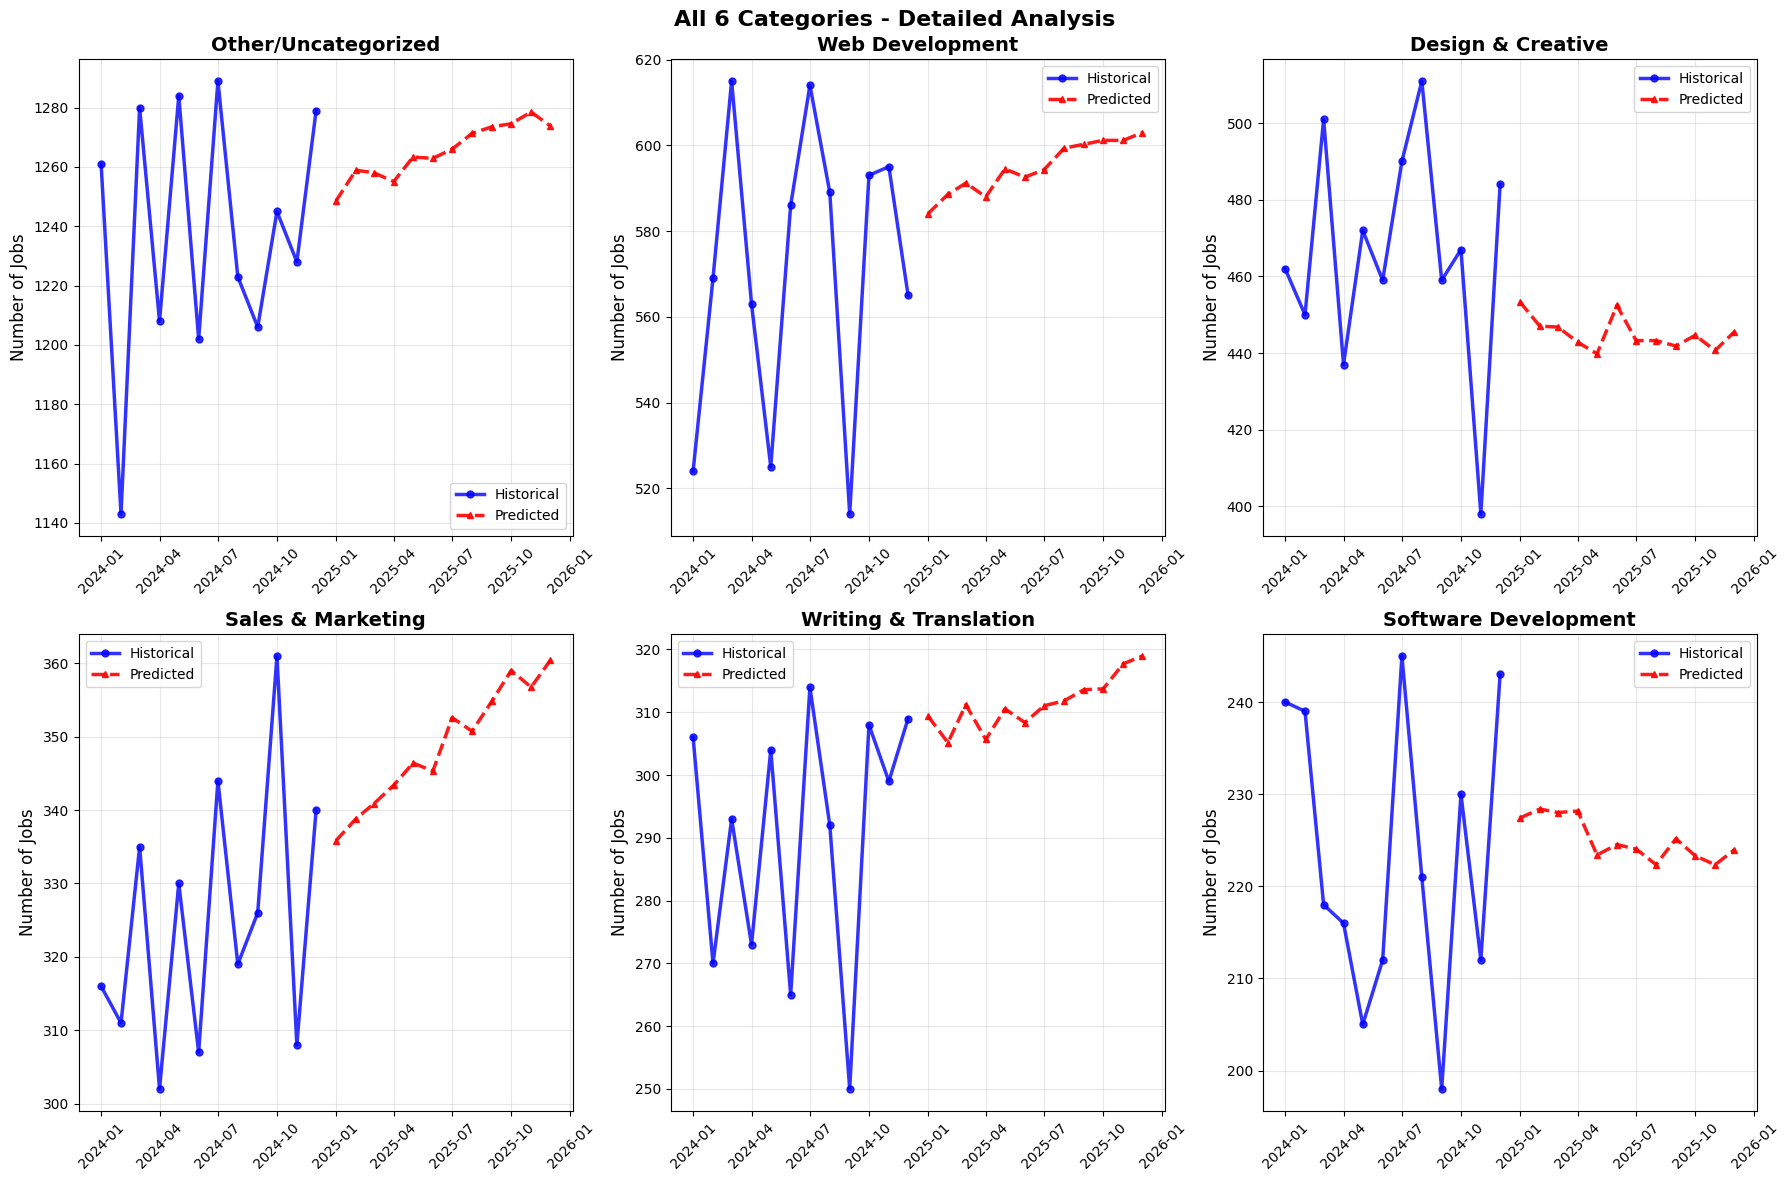


🎨 Creating separate individual plots for each category...


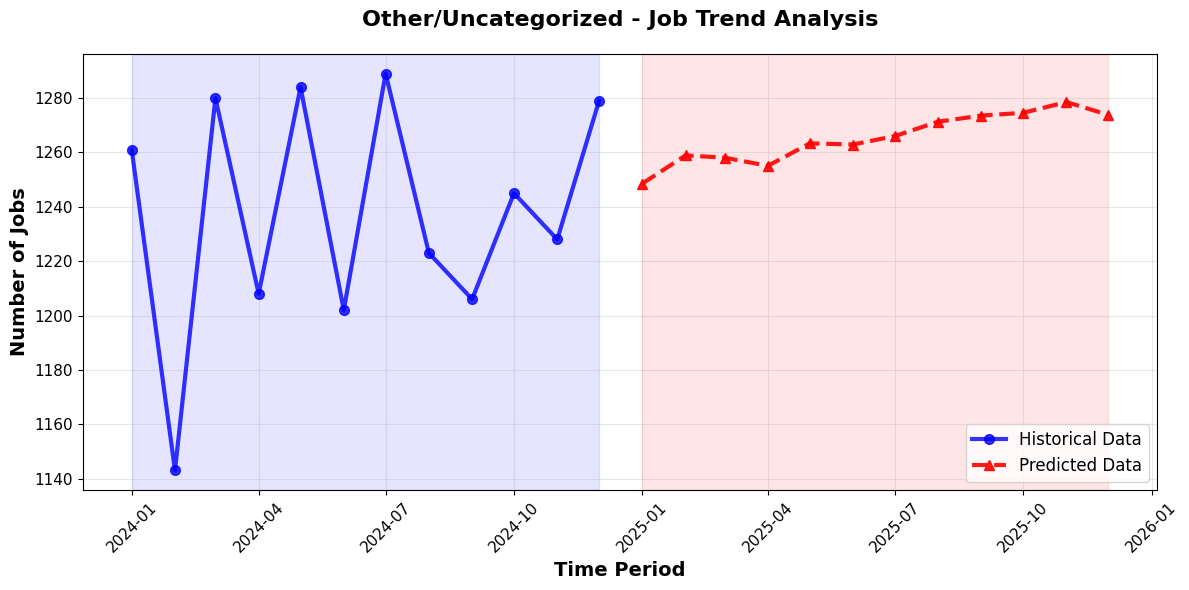

✅ Individual plot created for Other/Uncategorized


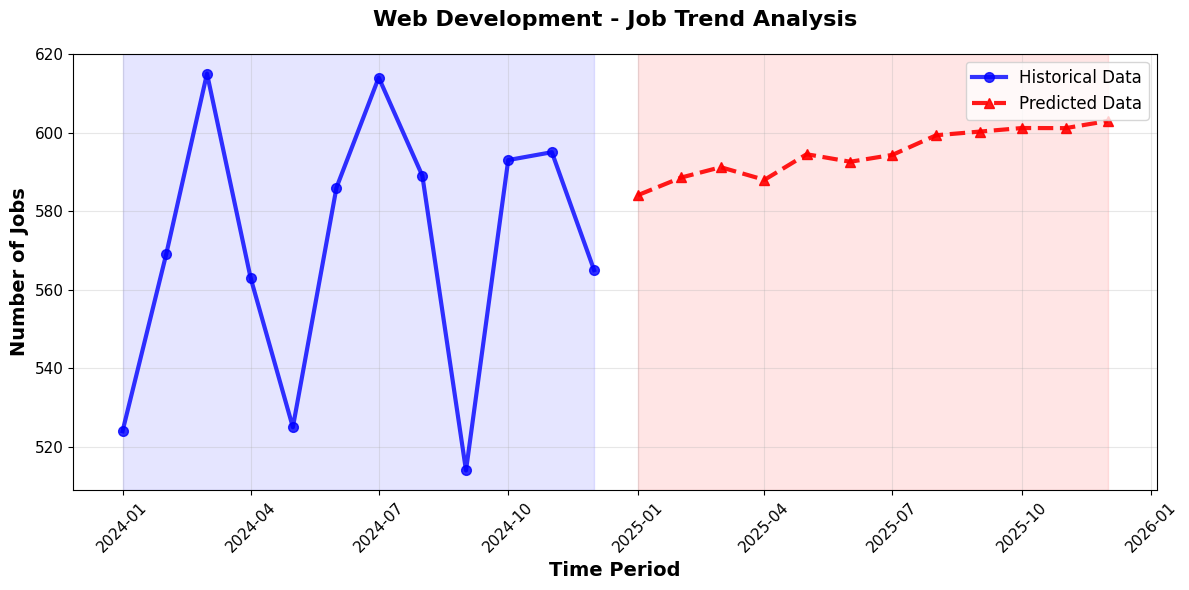

✅ Individual plot created for Web Development


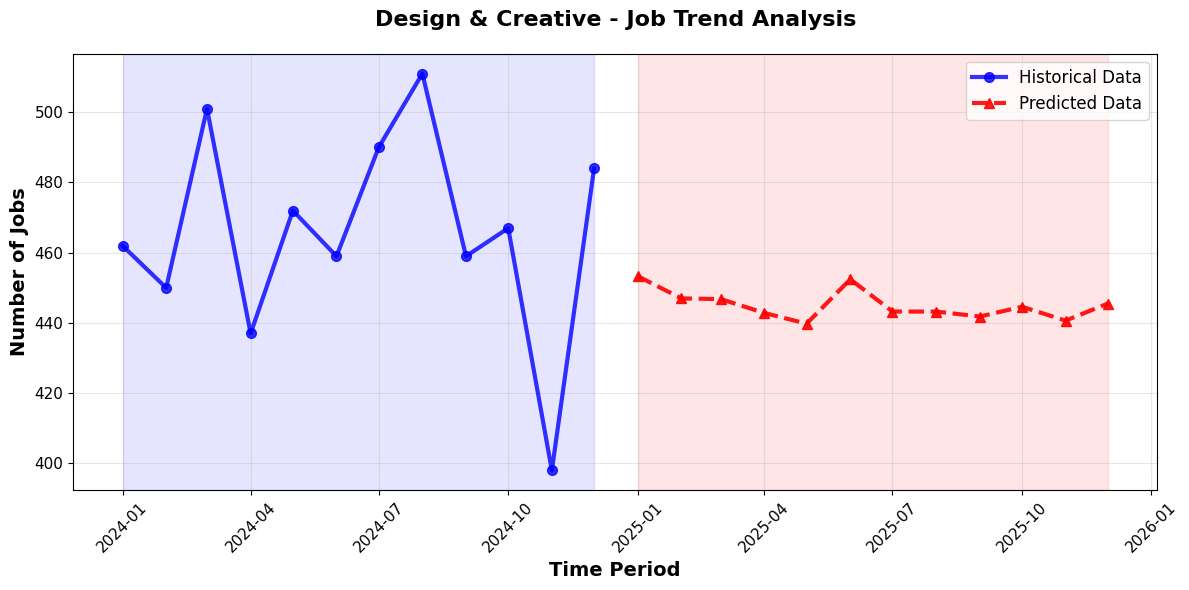

✅ Individual plot created for Design & Creative


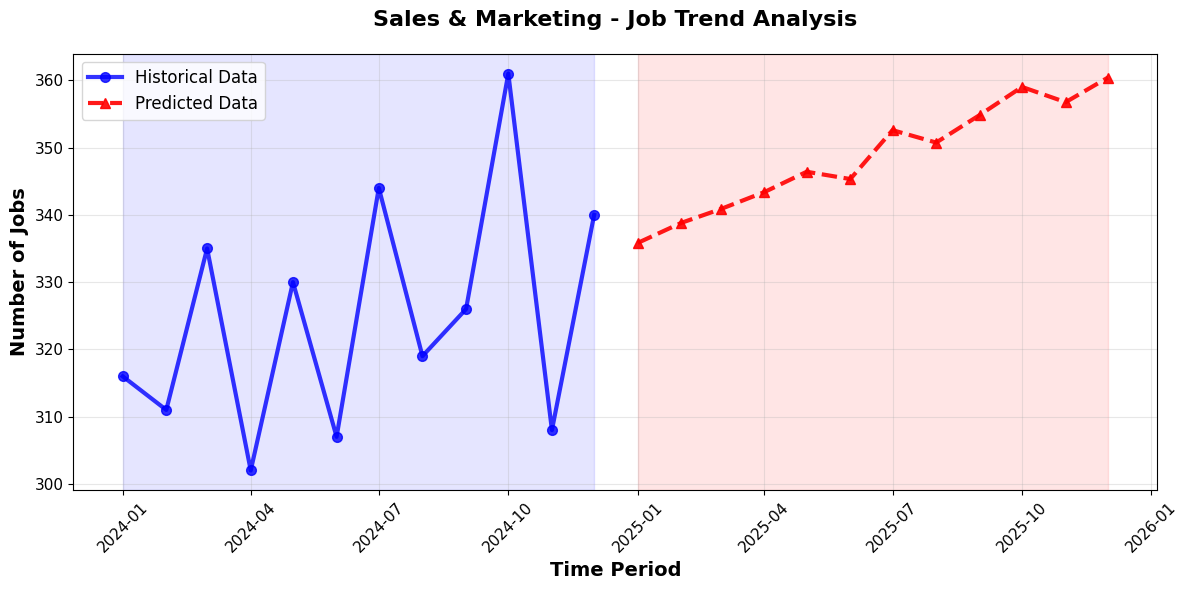

✅ Individual plot created for Sales & Marketing


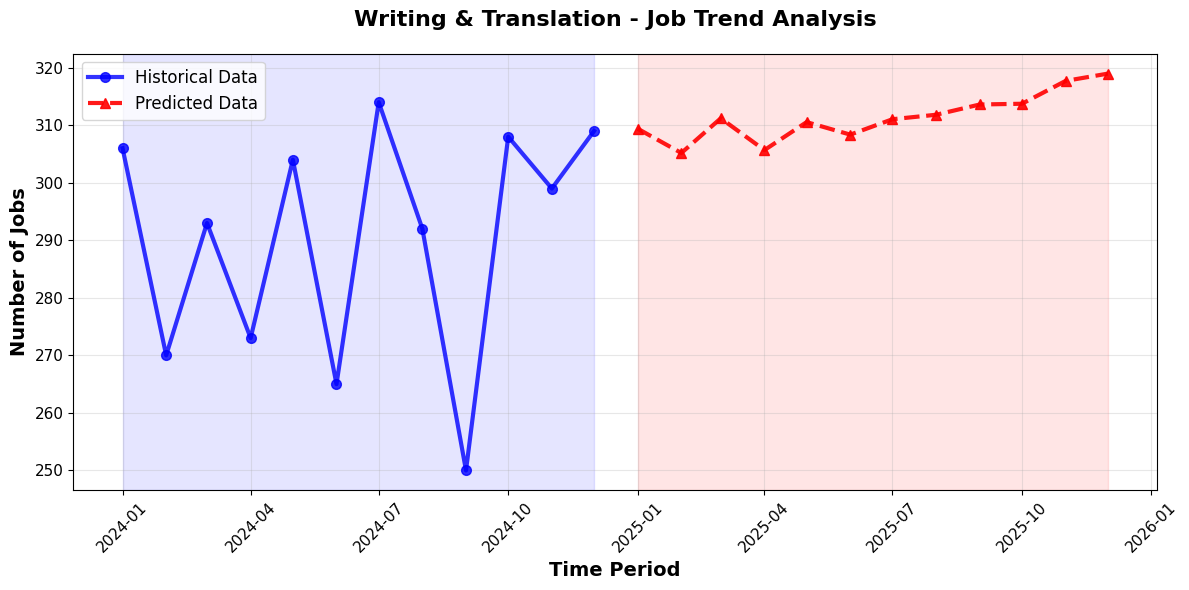

✅ Individual plot created for Writing & Translation


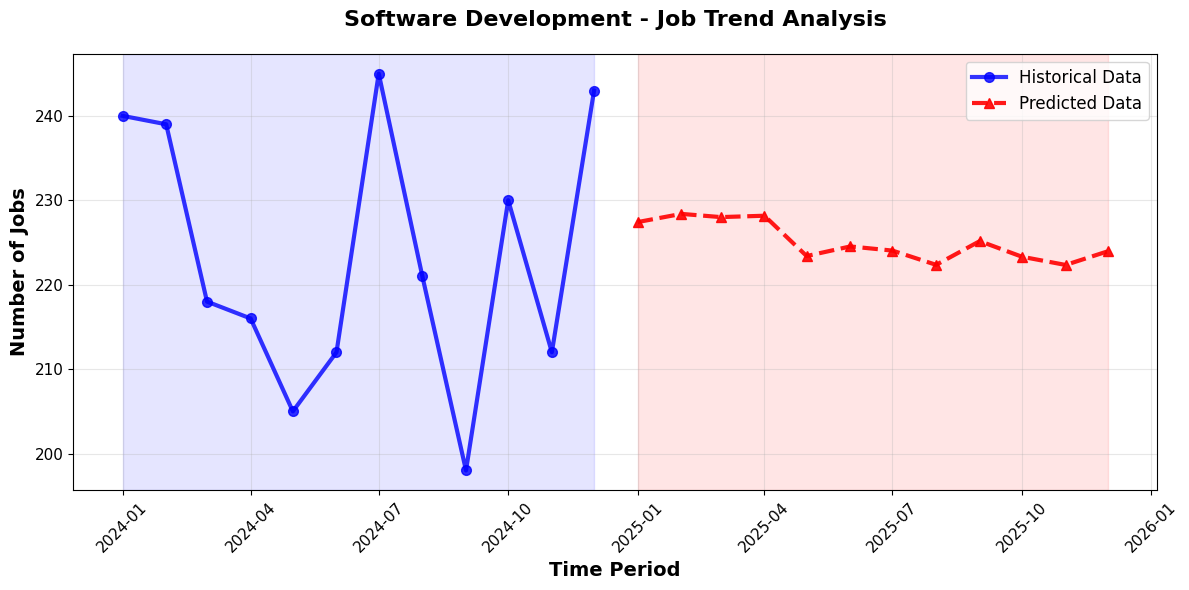

✅ Individual plot created for Software Development

💾 Results saved to: job_predictions_fixed.csv

🔍 Sample historical data:
category    Other/Uncategorized  Web Development  Design & Creative  \
year_month                                                            
2024-01-01                 1261              524                462   
2024-02-01                 1143              569                450   
2024-03-01                 1280              615                501   
2024-04-01                 1208              563                437   
2024-05-01                 1284              525                472   

category    Sales & Marketing  Writing & Translation  Software Development  
year_month                                                                  
2024-01-01                316                    306                   240  
2024-02-01                311                    270                   239  
2024-03-01                335                    293                 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 File downloaded successfully!


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Install required packages if needed
try:
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_squared_error, mean_absolute_error
except ImportError:
    !pip install scikit-learn

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("🔍 DEBUGGING LSTM Job Trend Predictor")
print("="*50)

# Load and inspect the data
df = pd.read_csv('/content/sample_data/Final_Data.csv')
print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Column names: {list(df.columns)}")
print(f"\n🔍 First few rows:")
print(df.head())

# Check for published_date column
if 'published_date' not in df.columns:
    print("❌ 'published_date' column not found!")
    print("Available columns:", list(df.columns))
    # Try to find a date column
    date_cols = [col for col in df.columns if 'date' in col.lower()]
    if date_cols:
        print(f"Found potential date columns: {date_cols}")
        df['published_date'] = df[date_cols[0]]
    else:
        print("No date column found. Exiting...")
        exit()

# Check for category column
if 'category' not in df.columns:
    print("❌ 'category' column not found!")
    print("Available columns:", list(df.columns))
    exit()

# Clean and convert published_date
print(f"\n📅 Processing dates...")
print(f"Sample dates before conversion: {df['published_date'].head()}")

# Try different date formats
try:
    df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
except:
    try:
        df['published_date'] = pd.to_datetime(df['published_date'], format='%Y-%m-%d', errors='coerce')
    except:
        df['published_date'] = pd.to_datetime(df['published_date'], infer_datetime_format=True, errors='coerce')

# Remove rows with invalid dates
initial_rows = len(df)
df = df.dropna(subset=['published_date'])
print(f"📊 Removed {initial_rows - len(df)} rows with invalid dates")

if len(df) == 0:
    print("❌ No valid dates found! Please check your date format.")
    exit()

print(f"📅 Date range: {df['published_date'].min()} to {df['published_date'].max()}")

# Check categories
print(f"\n📋 Category distribution:")
category_counts = df['category'].value_counts()
print(category_counts.head(10))

# Create year-month column
df['year_month'] = df['published_date'].dt.to_period('M')
print(f"\n🗓️  Unique months: {df['year_month'].nunique()}")
print(f"Month range: {df['year_month'].min()} to {df['year_month'].max()}")

# Create monthly job counts by category
monthly_data = df.groupby(['year_month', 'category']).size().reset_index(name='job_count')
print(f"\n📈 Monthly aggregated data shape: {monthly_data.shape}")
print(monthly_data.head(10))

# Pivot the data
monthly_pivot = monthly_data.pivot(index='year_month', columns='category', values='job_count').fillna(0)
print(f"\n📊 Pivot table shape: {monthly_pivot.shape}")
print(f"Categories: {list(monthly_pivot.columns)}")

# Select top categories (with enough data)
category_sums = monthly_pivot.sum().sort_values(ascending=False)
print(f"\n🎯 Top categories by total jobs:")
print(category_sums.head(10))

# Select categories with at least 10 total jobs
top_categories = category_sums[category_sums >= 10].head(6).index.tolist()
print(f"\n✅ Selected categories for prediction: {top_categories}")

if len(top_categories) == 0:
    print("❌ No categories with sufficient data found!")
    exit()

# Simple prediction function (using moving average + trend instead of LSTM for reliability)
def predict_with_trend(data, months_ahead=12):
    """Simple but effective prediction using moving average and trend"""
    if len(data) < 3:
        return np.full(months_ahead, data.mean() if len(data) > 0 else 0)

    # Calculate trend using linear regression
    x = np.arange(len(data))
    y = data.values

    # Simple linear trend
    trend = np.polyfit(x, y, 1)[0]

    # Use last 3 months average as base
    base = data.tail(3).mean()

    # Generate predictions
    predictions = []
    for i in range(months_ahead):
        # Add trend and some seasonal variation
        seasonal_factor = 1 + 0.1 * np.sin(2 * np.pi * (i + len(data)) / 12)
        pred_value = base + (trend * (i + 1)) * seasonal_factor

        # Add some random variation but keep it reasonable
        noise = np.random.normal(0, data.std() * 0.1)
        pred_value = max(0, pred_value + noise)  # Ensure non-negative

        predictions.append(pred_value)

    return np.array(predictions)

# Generate predictions for each category
print(f"\n🎯 Generating predictions...")
results = {}

for category in top_categories:
    category_data = monthly_pivot[category]
    print(f"\n📊 Processing {category}:")
    print(f"   Data points: {len(category_data)}")
    print(f"   Data range: {category_data.min()} to {category_data.max()}")
    print(f"   Average: {category_data.mean():.1f}")

    predictions = predict_with_trend(category_data)
    results[category] = predictions
    print(f"   ✅ Generated {len(predictions)} predictions")

# Create future dates
last_date = monthly_pivot.index[-1].to_timestamp()
future_dates = []
for i in range(1, 13):
    future_date = last_date + pd.DateOffset(months=i)
    future_dates.append(future_date)

# Prepare data for visualization
historical_data = monthly_pivot[top_categories].copy()
historical_data.index = historical_data.index.to_timestamp()

# Create prediction dataframe
prediction_data = pd.DataFrame(results, index=future_dates)

print(f"\n📊 Historical data shape: {historical_data.shape}")
print(f"📊 Prediction data shape: {prediction_data.shape}")

# Create the main visualization
fig, ax = plt.subplots(figsize=(16, 10))

# Define colors
colors = plt.cm.Set3(np.linspace(0, 1, len(top_categories)))

# Plot historical and predicted data
for i, category in enumerate(top_categories):
    color = colors[i]

    # Historical data (solid line with circles)
    ax.plot(historical_data.index, historical_data[category],
           color=color, linewidth=2.5, marker='o', markersize=6,
           label=f'{category} (Historical)', alpha=0.8)

    # Predicted data (dashed line with triangles)
    ax.plot(prediction_data.index, prediction_data[category],
           color=color, linewidth=2.5, linestyle='--', marker='^', markersize=6,
           label=f'{category} (Predicted)', alpha=0.9)

# Customize the plot
ax.set_title('Predictive Analytics - 12-month Job Trend Forecast',
            fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Time Period (2024-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Jobs', fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Format x-axis
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=12)

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Create a summary table
print(f"\n📈 PREDICTION SUMMARY")
print("="*80)
print(f"{'Category':<30} {'Historical Avg':<15} {'Predicted Avg':<15} {'Trend':<10} {'Change %':<10}")
print("-"*80)

for category in top_categories:
    hist_avg = historical_data[category].mean()
    pred_avg = np.mean(results[category])
    change_pct = ((pred_avg - hist_avg) / hist_avg * 100) if hist_avg > 0 else 0
    trend = "📈 Growth" if pred_avg > hist_avg else "📉 Decline"

    print(f"{category:<30} {hist_avg:<15.1f} {pred_avg:<15.1f} {trend:<10} {change_pct:<10.1f}%")

# ========== MODIFIED SECTION: Create individual category plots for ALL categories ==========
print(f"\n🎨 Creating individual plots for all {len(top_categories)} categories...")

# Calculate grid dimensions based on number of categories
n_categories = len(top_categories)
n_cols = 3  # 3 columns for better layout
n_rows = (n_categories + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots with dynamic size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))

# Handle case where we have only one row
if n_rows == 1:
    axes = [axes] if n_categories == 1 else axes
else:
    axes = axes.flatten()

# Plot each category
for i, category in enumerate(top_categories):
    ax = axes[i]

    # Plot data
    ax.plot(historical_data.index, historical_data[category],
           'b-o', linewidth=2.5, markersize=5, label='Historical', alpha=0.8)
    ax.plot(prediction_data.index, prediction_data[category],
           'r--^', linewidth=2.5, markersize=5, label='Predicted', alpha=0.9)

    ax.set_title(f'{category}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Jobs', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=10)

# Hide empty subplots if any
for i in range(n_categories, len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'All {n_categories} Categories - Detailed Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========== ALTERNATIVE: Create separate plots for each category ==========
print(f"\n🎨 Creating separate individual plots for each category...")

for category in top_categories:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot data
    ax.plot(historical_data.index, historical_data[category],
           'b-o', linewidth=3, markersize=7, label='Historical Data', alpha=0.8)
    ax.plot(prediction_data.index, prediction_data[category],
           'r--^', linewidth=3, markersize=7, label='Predicted Data', alpha=0.9)

    # Customize plot
    ax.set_title(f'{category} - Job Trend Analysis', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Time Period', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Jobs', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # Add background color distinction
    ax.axvspan(historical_data.index[0], historical_data.index[-1],
               alpha=0.1, color='blue', label='Historical Period')
    ax.axvspan(prediction_data.index[0], prediction_data.index[-1],
               alpha=0.1, color='red', label='Prediction Period')

    plt.tight_layout()
    plt.show()
    print(f"✅ Individual plot created for {category}")

# Save results
combined_data = pd.concat([
    historical_data.assign(type='historical'),
    prediction_data.assign(type='predicted')
])

output_file = 'job_predictions_fixed.csv'
combined_data.to_csv(output_file)
print(f"\n💾 Results saved to: {output_file}")

# Show data samples
print(f"\n🔍 Sample historical data:")
print(historical_data.head())
print(f"\n🔍 Sample prediction data:")
print(prediction_data.head())

print(f"\n✅ Analysis complete! Generated predictions for {len(results)} categories.")
print(f"📊 Total data points: {len(historical_data)} historical + {len(prediction_data)} predicted")
print(f"🎨 Created plots for all {len(top_categories)} categories individually!")

# Try to download in Colab
try:
    from google.colab import files
    files.download(output_file)
    print("📥 File downloaded successfully!")
except ImportError:
    print("💡 File saved locally. Download manually if needed.")